<a href="https://colab.research.google.com/github/Bhuvana908/Diabetic-Retinopathy-using-AI-ML-Summer-Research-Internship-NITC-/blob/main/DR1/DR1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle scikit-image seaborn joblib tqdm albumentations grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 74.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kadasanibhuvanareddy","key":"23ee06c6239c3d9d3113e1a9131b64eb"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle configured")

✅ Kaggle configured


In [ ]:
import os

DOWNLOAD_DIR = "/content/aptos"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

!kaggle datasets download \
-d mariaherrerot/aptos2019 \
-p {DOWNLOAD_DIR}

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [07:42<00:00, 18.6MB/s]



In [ ]:
!ls -lh /content/aptos

total 8.1G
-rw-r--r-- 1 root root 8.1G Nov 17  2021 aptos2019.zip


In [ ]:
!unzip -q /content/aptos/aptos2019.zip -d /content/aptos

print("✅ Dataset extracted")

✅ Dataset extracted


In [ ]:
import os

for root, dirs, files in os.walk("/content/aptos"):
    print(root)
    print("Folders:", dirs[:3])
    print("Files:", files[:3])
    print("-"*40)

/content/aptos
Folders: ['train_images', 'val_images', 'test_images']
Files: ['valid.csv', 'train_1.csv', 'aptos2019.zip']
----------------------------------------
/content/aptos/train_images
Folders: ['train_images']
Files: []
----------------------------------------
/content/aptos/train_images/train_images
Folders: []
Files: ['810d3779abd9.png', 'a8652b2de23f.png', 'cd563556cb57.png']
----------------------------------------
/content/aptos/val_images
Folders: ['val_images']
Files: []
----------------------------------------
/content/aptos/val_images/val_images
Folders: []
Files: ['03c85870824c.png', '0d9a9896f801.png', '10f36b0239fb.png']
----------------------------------------
/content/aptos/test_images
Folders: ['test_images']
Files: []
----------------------------------------
/content/aptos/test_images/test_images
Folders: []
Files: ['fecf4c5ae84b.png', 'f850cb51fdba.png', 'f2094a20b275.png']
----------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path
from tqdm import tqdm

from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from skimage import measure
from skimage.feature import graycomatrix, graycoprops

print("✅ Libraries imported")

✅ Libraries imported


In [ ]:
from pathlib import Path

DATA_DIR = Path("/content/aptos")

TRAIN_CSV = DATA_DIR / "train_1.csv"

IMG_DIR = DATA_DIR / "train_images/train_images"

GRADE_LABELS = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

print("CSV Path:")
print(TRAIN_CSV)

print("\nImage Folder:")
print(IMG_DIR)

CSV Path:
/content/aptos/train_1.csv

Image Folder:
/content/aptos/train_images/train_images


In [ ]:
import pandas as pd
import os

df = pd.read_csv(TRAIN_CSV)

print("CSV Loaded Successfully")

print("\nColumns:")
print(df.columns)

# Create image paths
df["img_path"] = df["id_code"].apply(
    lambda x: str(IMG_DIR / f"{x}.png")
)

# Check file existence
df["exists"] = df["img_path"].apply(os.path.isfile)

# Map labels
df["grade_name"] = df["diagnosis"].map(GRADE_LABELS)

# Keep only existing images
df = df[df["exists"]]

df = df.reset_index(drop=True)

print(f"\n✅ Total images loaded: {len(df)}")

df.head()

CSV Loaded Successfully

Columns:
Index(['id_code', 'diagnosis'], dtype='object')

✅ Total images loaded: 2930


,id_code,diagnosis,img_path,exists,grade_name
0,1ae8c165fd53,2,/content/aptos/train_images/train_images/1ae8c...,True,Moderate
1,1b329a127307,1,/content/aptos/train_images/train_images/1b329...,True,Mild
2,1b32e1d775ea,4,/content/aptos/train_images/train_images/1b32e...,True,Proliferative DR
3,1b3647865779,0,/content/aptos/train_images/train_images/1b364...,True,No DR
4,1b398c0494d1,0,/content/aptos/train_images/train_images/1b398...,True,No DR


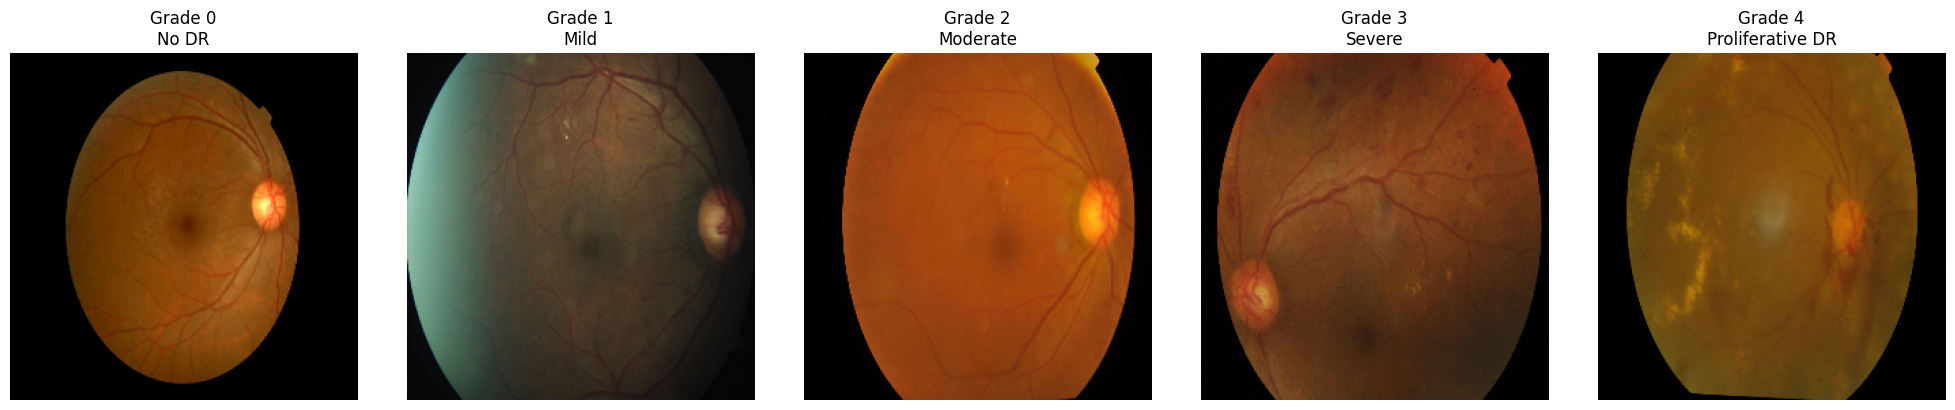

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for grade in range(5):

    row = df[df["diagnosis"] == grade].iloc[0]

    img = cv2.cvtColor(
        cv2.imread(row["img_path"]),
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(img, (256, 256))

    axes[grade].imshow(img)

    axes[grade].set_title(
        f"Grade {grade}\n{GRADE_LABELS[grade]}"
    )

    axes[grade].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!pip install -q albumentations efficientnet-pytorch

  Preparing metadata (setup.py) ... done


In [ ]:
import os, cv2, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler  # WeightedRandomSampler is NEW
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR                           # replaces CosineAnnealingLR
from pathlib import Path
from tqdm import tqdm
from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from skimage import measure
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, cohen_kappa_score)    # cohen_kappa_score is NEW
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("✅ All libraries imported")

✅ All libraries imported


In [ ]:
IMG_SIZE = 512

def extract_green_channel(img_rgb):
    """
    Paper Section: Green Channel Extraction.
    The green channel gives the best contrast between blood vessels,
    exudates, and hemorrhages — neither under-illuminated nor over-saturated.
    Returns a 3-channel image where only the green channel is used for analysis,
    but we keep RGB shape for CNN compatibility.
    """
    green = img_rgb[:, :, 1]  # extract green channel
    # Stack into 3-channel for CNN (green replicated across channels)
    return np.stack([green, green, green], axis=-1)


def apply_clahe(img_rgb):
    """
    Paper Section: Contrast Enhancement.
    CLAHE (Contrast Limited Adaptive Histogram Equalization) divides the image
    into small blocks and equalizes each block independently.
    Applied to the green channel to enhance vessels, exudates, hemorrhages.
    """
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    channels = list(cv2.split(img_rgb))
    channels[1] = clahe.apply(channels[1])  # enhance green channel only
    return cv2.merge(channels)


def crop_to_field_of_view(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    coords = np.argwhere(mask)
    if coords.size == 0:
        return img
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]   # removed re-padding — black border gone


def preprocess_image(path, return_rgb=False):
    """
    Full preprocessing pipeline from the research paper:
    1. Load image
    2. Green channel extraction (best contrast for DR features)
    3. CLAHE contrast enhancement
    4. Crop to field of view (remove black border)
    5. Resize to 512x512
    Returns float32 image normalized to [0,1].
    Set return_rgb=True to also get the original RGB for visualization.
    """
    img = cv2.imread(str(path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Step 1: CLAHE on original RGB (enhances green channel)
    img_clahe = apply_clahe(img_rgb)

    # Step 2: Crop to field of view
    img_cropped = crop_to_field_of_view(img_clahe)

    # Step 3: Resize to 512x512
    img_resized = cv2.resize(img_cropped, (IMG_SIZE, IMG_SIZE))

    # Step 4: Extract green channel (paper: best for DR feature visibility)
    img_green = extract_green_channel(img_resized)

    # Normalize to [0, 1]
    img_out = img_green.astype(np.float32) / 255.0

    if return_rgb:
        return img_out, img_resized  # also return colour version for viz
    return img_out


print("✅ Preprocessing functions defined (green channel + CLAHE + FOV crop + resize)")

✅ Preprocessing functions defined (green channel + CLAHE + FOV crop + resize)


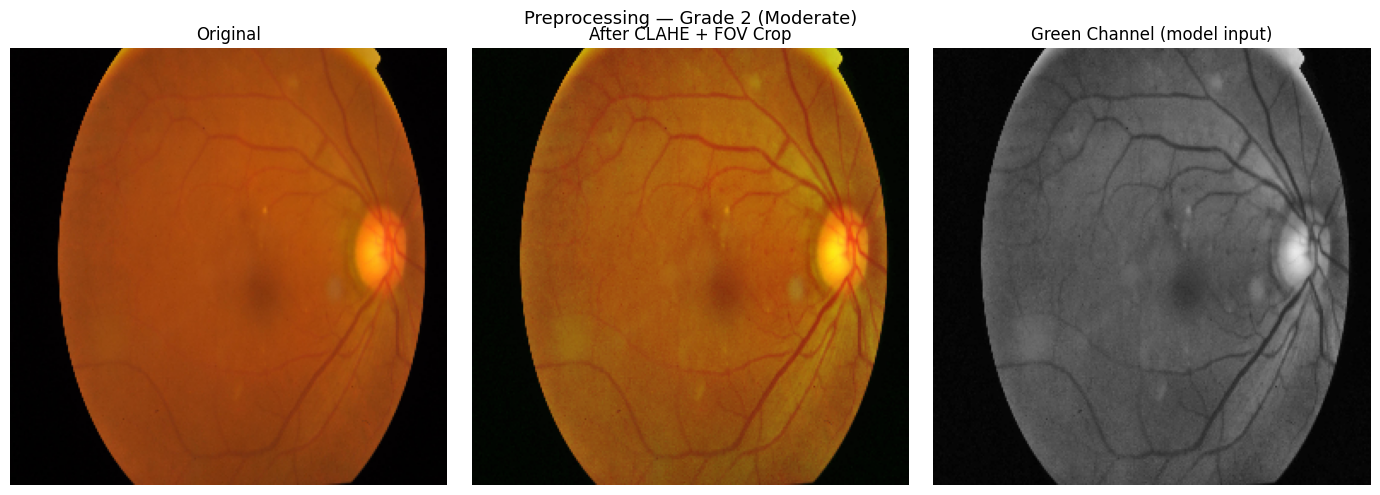

In [ ]:
# Pick any one image — change grade or index as you like
sample_row = df[df["diagnosis"] == 2].iloc[0]

# --- Original ---
raw = cv2.cvtColor(cv2.imread(sample_row["img_path"]), cv2.COLOR_BGR2RGB)
raw = cv2.resize(raw, (256, 256))

# --- After CLAHE + crop ---
img_clahe_crop = apply_clahe(raw)
img_clahe_crop = crop_to_field_of_view(img_clahe_crop)
img_clahe_crop = cv2.resize(img_clahe_crop, (256, 256))

# --- Green channel ---
img_green_only = extract_green_channel(img_clahe_crop)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(raw)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_clahe_crop)
axes[1].set_title("After CLAHE + FOV Crop")
axes[1].axis("off")

axes[2].imshow(img_green_only)
axes[2].set_title("Green Channel (model input)")
axes[2].axis("off")

plt.suptitle(
    f"Preprocessing — Grade {sample_row['diagnosis']} ({GRADE_LABELS[sample_row['diagnosis']]})",
    fontsize=13
)
plt.tight_layout()
plt.show()

In [ ]:
GLCM_PROPS = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]


# ── COLOR FEATURES (paper: mean & std of green channel pixels) ──────────────
def extract_color_features(pixels_green):
    """
    Paper: color statistics from green channel.
    pixels_green: 1D array of green channel pixel values in the superpixel.
    Returns mean and std (2 features).
    """
    return np.array([
        pixels_green.mean(),
        pixels_green.std()
    ])


# ── GLCM TEXTURE FEATURES (paper: GLCM on green channel) ────────────────────
def extract_glcm_texture(patch_green_uint8):
    """
    Paper: GLCM texture features on green channel patch.
    Features: contrast, dissimilarity, homogeneity, energy, correlation.
    High contrast + low homogeneity → textured → likely vessel or lesion region.
    """
    if patch_green_uint8.shape[0] < 2 or patch_green_uint8.shape[1] < 2:
        return np.zeros(len(GLCM_PROPS))
    glcm = graycomatrix(
        patch_green_uint8,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )
    return np.array([graycoprops(glcm, p)[0, 0] for p in GLCM_PROPS])


# ── SHAPE FEATURES (paper: area, perimeter, eccentricity, solidity, extent) ──
def extract_shape_features(binary_mask):
    """
    Paper: morphological shape features of the superpixel region.
    area: size of the superpixel (paper: exudate area, vessel area)
    eccentricity: elongation (vessels are elongated, exudates are compact)
    solidity: how filled the shape is
    """
    props = measure.regionprops((binary_mask).astype(int))
    if not props:
        return np.zeros(5)
    p = props[0]
    return np.array([
        p.area,
        p.perimeter,
        p.eccentricity,
        p.solidity,
        p.extent
    ])


# ── SHANNON ENTROPY (paper: Shannon entropy feature) ────────────────────────
def extract_shannon_entropy(pixels_green):
    """
    Paper: Shannon entropy — expected average information in each pixel.
    Diabetic retinopathy images show significantly lower entropy than normal.
    """
    hist, _ = np.histogram(pixels_green, bins=32, range=(0, 1), density=True)
    hist = hist + 1e-10  # avoid log(0)
    return np.array([-(hist * np.log2(hist)).sum()])


# ── EXUDATE-LIKENESS SCORE (paper: exudate area = highest ranked feature) ───
def exudate_score(pixels_rgb):
    """
    Paper: Exudate area is the best-ranked feature with mean difference of 1029.7.
    Exudates are bright yellowish-white spots: high R, high G, low B.
    Completely absent in normal images; present in all DR stages.
    """
    r = pixels_rgb[:, 0].mean()
    g = pixels_rgb[:, 1].mean()
    b = pixels_rgb[:, 2].mean()
    # Yellow-white: R and G both high, B low
    score = max(0.0, (r + g) / 2 - b)
    return np.array([score])


# ── VESSEL-LIKENESS SCORE (paper: blood vessel area, bifurcation count) ──────
def vessel_score(pixels_rgb, shape_feats):
    """
    Paper: Blood vessel area has high mean difference (38486 normal vs 34672 DR).
    Vessels are dark reddish, elongated (high eccentricity), with high contrast.
    """
    r = pixels_rgb[:, 0].mean()
    g = pixels_rgb[:, 1].mean()
    b = pixels_rgb[:, 2].mean()
    eccentricity = shape_feats[2]  # elongated = vessel-like
    darkness = 1 - g               # vessels are dark on green channel
    score = darkness * eccentricity * max(0, r - b)
    return np.array([score])


# ── HEMORRHAGE/MA SCORE (paper: hemorrhage area, microaneurysm area) ─────────
def hemorrhage_ma_score(pixels_rgb, shape_feats):
    """
    Paper: Hemorrhages and MAs are red lesions, small, roughly circular (low eccentricity).
    MAs are the earliest clinical sign of DR.
    """
    r = pixels_rgb[:, 0].mean()
    g = pixels_rgb[:, 1].mean()
    b = pixels_rgb[:, 2].mean()
    area = shape_feats[0]
    eccentricity = shape_feats[2]
    # Red, small, compact
    redness = max(0, r - g - b + 0.1)
    compactness = 1 - eccentricity  # circular = low eccentricity
    # Penalise very large regions (MAs and HMs are small)
    size_penalty = np.exp(-area / 5000)
    score = redness * compactness * size_penalty
    return np.array([score])




In [ ]:
N_SEGMENTS = 200

def generate_superpixels(image_float):
    """
    SLIC superpixel segmentation.
    image_float: float32 image in [0,1], shape (512,512,3).
    Returns integer label map of shape (512,512).
    """
    return slic(
        img_as_float(image_float),
        n_segments=N_SEGMENTS,
        compactness=10,
        sigma=1,
        start_label=0,
        channel_axis=-1
    )


def score_one_superpixel(img_float, img_rgb_uint8, mask):
    """
    Compute the full paper-based feature vector and relevance score
    for a single superpixel defined by binary mask.

    img_float     : preprocessed green-channel float image (512,512,3)
    img_rgb_uint8 : original colour image uint8 (512,512,3) for RGB features
    mask          : boolean mask (512,512) for this superpixel

    Returns (feature_vector, relevance_score).
    """
    pixels_green = img_float[mask, 1]            # green channel pixels
    pixels_rgb   = img_rgb_uint8[mask].astype(np.float32) / 255.0

    # Hard filter: discard black-border superpixels immediately
    if pixels_green.mean() < 0.05:
        return None, 0.0

    # Get bounding box patch for GLCM
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    green_uint8 = (img_float[:, :, 1] * 255).astype(np.uint8)
    patch_g = green_uint8[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]

    # Extract all paper features
    color_feats   = extract_color_features(pixels_green)           # 2
    glcm_feats    = extract_glcm_texture(patch_g)                  # 5
    shape_feats   = extract_shape_features(mask)                   # 5
    entropy_feats = extract_shannon_entropy(pixels_green)          # 1
    exudate_f     = exudate_score(pixels_rgb)                      # 1
    vessel_f      = vessel_score(pixels_rgb, shape_feats)          # 1
    hm_ma_f       = hemorrhage_ma_score(pixels_rgb, shape_feats)   # 1

    feature_vector = np.concatenate([
        color_feats, glcm_feats, shape_feats,
        entropy_feats, exudate_f, vessel_f, hm_ma_f
    ])  # total: 16 features (matches paper's 14+ features)

    # ── Relevance score (weighted sum of paper-ranked features) ──────────────
    # Paper ranking: exudate area (1st) > blood vessel (2nd) > bifurcation >
    #                Shannon entropy > optic distance > hemorrhage > MA
    glcm_contrast    = glcm_feats[0]
    glcm_homogeneity = glcm_feats[2]
    texture          = glcm_contrast * (1 - glcm_homogeneity)

    relevance = (
        0.35 * float(exudate_f[0])   +   # paper rank 1: exudate area
        0.25 * float(vessel_f[0])    +   # paper rank 2: blood vessel area
        0.20 * float(hm_ma_f[0])    +   # paper rank 6&7: hemorrhage & MA
        0.15 * texture               +   # paper rank 4: Shannon entropy proxy
        0.05 * float(entropy_feats[0]) / 10  # paper rank 4: Shannon entropy
    )

    return feature_vector, relevance


print("✅ Superpixel scoring function defined")

✅ Superpixel scoring function defined


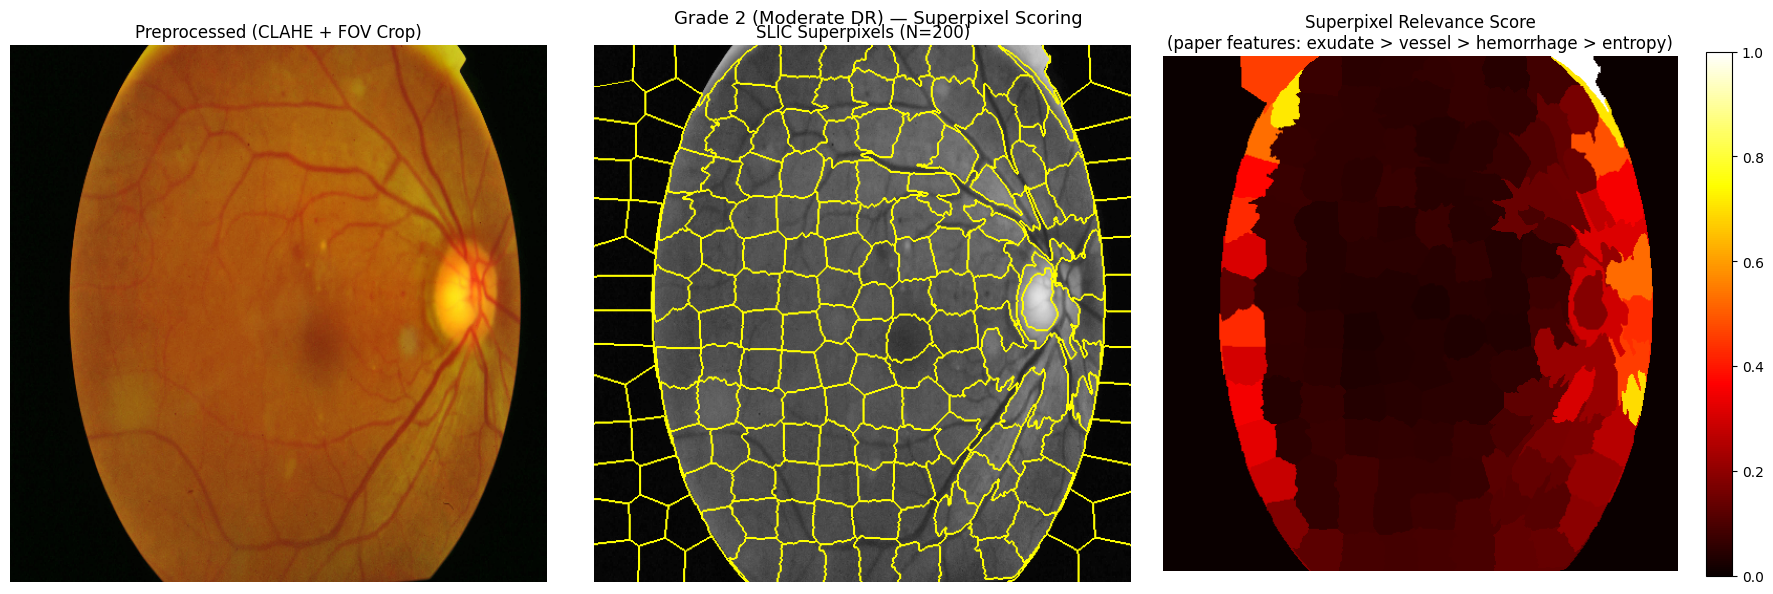

In [ ]:
sample_row = df[df["diagnosis"] == 2].iloc[0]  # moderate DR sample

img_float, img_rgb = preprocess_image(sample_row["img_path"], return_rgb=True)
segs = generate_superpixels(img_float)

# Score all superpixels
score_map = np.zeros(img_float.shape[:2], dtype=np.float32)
for label in np.unique(segs):
    mask = segs == label
    _, score = score_one_superpixel(img_float, img_rgb, mask)
    score_map[mask] = score

# Normalize score map for visualization
score_vis = (score_map - score_map.min()) / (score_map.max() - score_map.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Preprocessed (CLAHE + FOV Crop)")
axes[0].axis("off")

boundary_img = mark_boundaries(img_float, segs, color=(1, 1, 0))
axes[1].imshow(boundary_img)
axes[1].set_title(f"SLIC Superpixels (N={N_SEGMENTS})")
axes[1].axis("off")

heatmap = axes[2].imshow(score_vis, cmap="hot")
axes[2].set_title("Superpixel Relevance Score\n(paper features: exudate > vessel > hemorrhage > entropy)")
axes[2].axis("off")
plt.colorbar(heatmap, ax=axes[2], fraction=0.046)

plt.suptitle(f"Grade 2 (Moderate DR) — Superpixel Scoring", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
PATCH_SIZE = 64   # resize each superpixel patch to this for CNN
TOP_K      = 25   # keep top-25 highest-scoring superpixels per image

def extract_topk_patches(img_path, top_k=TOP_K):
    """
    Full pipeline for one image:
    1. Preprocess (green channel + CLAHE + FOV crop + resize)
    2. Generate SLIC superpixels
    3. Score each superpixel using paper's features
    4. Keep top-K by relevance score
    5. Return list of (patch_uint8 64x64, feature_vector, score)
    """
    img_float, img_rgb = preprocess_image(img_path, return_rgb=True)
    segs = generate_superpixels(img_float)

    scored = []
    for label in np.unique(segs):
        mask = segs == label
        feat_vec, score = score_one_superpixel(img_float, img_rgb, mask)
        if feat_vec is not None:
            scored.append((label, score, feat_vec, mask))

    # Sort by descending relevance score — paper rank order preserved
    scored.sort(key=lambda x: -x[1])

    patches = []
    for label, score, feat_vec, mask in scored[:top_k]:
        rows = np.where(mask.any(axis=1))[0]
        cols = np.where(mask.any(axis=0))[0]
        if len(rows) < 4 or len(cols) < 4:
            continue
        # Crop bounding box of this superpixel from preprocessed image
        patch = img_rgb[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]
        patch = cv2.resize(patch, (PATCH_SIZE, PATCH_SIZE))
        patches.append((patch, feat_vec, score))

    return patches


print("✅ Top-K patch extraction function defined")

✅ Top-K patch extraction function defined


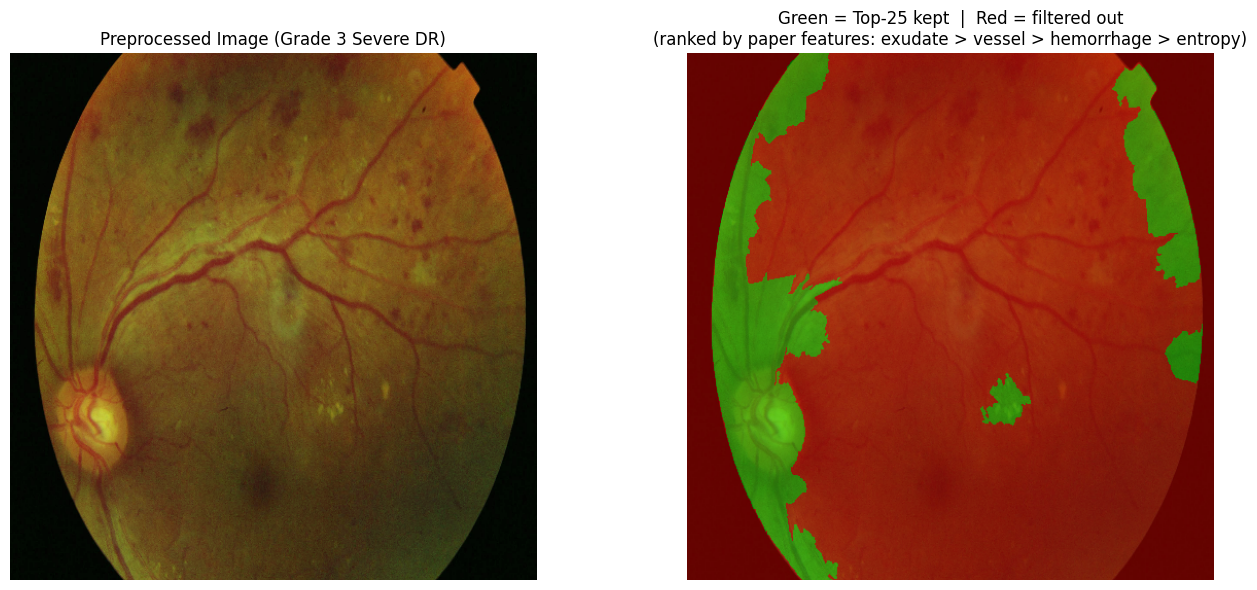

In [ ]:
sample_row = df[df["diagnosis"] == 3].iloc[0]  # severe DR

img_float, img_rgb = preprocess_image(sample_row["img_path"], return_rgb=True)
segs = generate_superpixels(img_float)

all_scores = []
for label in np.unique(segs):
    mask = segs == label
    _, score = score_one_superpixel(img_float, img_rgb, mask)
    all_scores.append((label, score))
all_scores.sort(key=lambda x: -x[1])

top_labels      = set([l for l, _ in all_scores[:TOP_K]])
filtered_labels = set([l for l, _ in all_scores[TOP_K:]])

# Build coloured overlay: green = kept, red = filtered
overlay = img_rgb.copy()
for label, score in all_scores:
    mask = segs == label
    if label in top_labels:
        overlay[mask] = (overlay[mask] * 0.5 + np.array([0, 200, 0]) * 0.5).astype(np.uint8)
    else:
        overlay[mask] = (overlay[mask] * 0.5 + np.array([200, 0, 0]) * 0.5).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Preprocessed Image (Grade 3 Severe DR)")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title(f"Green = Top-{TOP_K} kept  |  Red = filtered out\n(ranked by paper features: exudate > vessel > hemorrhage > entropy)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# ── SUPERPIXEL ATTENTION MASK (replaces extract_topk_patches entirely) ────────
def get_superpixel_mask(img_rgb_uint8, n_segments=100, top_k=25):
    """
    Builds a soft attention mask from superpixel relevance scores.
    Top-K superpixels get weight 1.0, rest get 0.15 (not zero — preserves context).
    Takes ~1-2s per image, done on-the-fly inside Dataset.__getitem__.
    """
    img_float = img_rgb_uint8.astype(np.float32) / 255.0
    segs      = slic(img_float, n_segments=n_segments,
                     compactness=10, sigma=1,
                     start_label=0, channel_axis=-1)

    scores = {}
    for label in np.unique(segs):
        mask        = segs == label
        _, score    = score_one_superpixel(img_float, img_rgb_uint8, mask)
        scores[label] = score

    # Rank superpixels, build mask
    sorted_labels = sorted(scores, key=scores.get, reverse=True)
    top_labels    = set(sorted_labels[:top_k])

    attention = np.full(segs.shape, 0.15, dtype=np.float32)  # dim background
    for label in top_labels:
        attention[segs == label] = 1.0                        # highlight top-K

    return attention[:, :, np.newaxis]  # (H, W, 1) — broadcast over RGB




In [ ]:
from multiprocessing import Pool

# ── STEP 1: Precompute all masked images once ──────────────────────────────
def compute_mask_for_row(args):
    img_path, idx = args
    try:
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = apply_clahe(img)
        img = crop_to_field_of_view(img)
        img = cv2.resize(img, (380, 380))
        mask = get_superpixel_mask(img)
        img_masked = (img.astype(np.float32) * mask).astype(np.uint8)
        return idx, img_masked
    except Exception as e:
        print(f"⚠ {img_path}: {e}")
        return idx, None

df["orig_idx"] = range(len(df))   # track index through train/val split
args_list = [(row["img_path"], i) for i, (_, row) in enumerate(df.iterrows())]

print("Precomputing superpixel masks (runs once, ~5-8 min)...")
precomputed = {}
with Pool(processes=4) as pool:
    for idx, img_masked in tqdm(
        pool.imap(compute_mask_for_row, args_list, chunksize=8),
        total=len(args_list), desc="Masking"
    ):
        if img_masked is not None:
            precomputed[idx] = img_masked

print(f"✅ Done — {len(precomputed)} images masked and stored in RAM")

# ── STEP 2: Dataset reads from RAM — zero cost per batch ──────────────────
IMG_SIZE = 380

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class RetinopathyDataset(Dataset):
    def __init__(self, dataframe, precomputed_imgs, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.precomp   = precomputed_imgs
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        orig_idx = self.df.iloc[idx]["orig_idx"]
        img      = self.precomp[orig_idx].copy()
        if self.transform:
            img = self.transform(image=img)["image"]
        label = torch.tensor(self.df.iloc[idx]["diagnosis"], dtype=torch.long)
        return img, label

# ── STEP 3: Split and build loaders ───────────────────────────────────────
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["diagnosis"], random_state=42
)

train_ds = RetinopathyDataset(train_df, precomputed, train_transform)
val_ds   = RetinopathyDataset(val_df,   precomputed, val_transform)

class_counts     = np.bincount(train_df["diagnosis"].values, minlength=5)
class_weights_np = 1.0 / (class_counts.astype(float) + 1e-6)
sample_weights   = [class_weights_np[l] for l in train_df["diagnosis"].values]

sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(train_df), replacement=True
)

train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"✅ Train: {len(train_ds)} | Val: {len(val_ds)}")
print(f"Class counts: {dict(enumerate(class_counts))}")

Precomputing superpixel masks (runs once, ~5-8 min)...


Masking: 100%|██████████| 2930/2930 [38:45<00:00,  1.26it/s]

✅ Done — 2930 images masked and stored in RAM
✅ Train: 2344 | Val: 586
Class counts: {0: np.int64(1147), 1: np.int64(240), 2: np.int64(647), 3: np.int64(123), 4: np.int64(187)}



/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

def build_model(num_classes=5):
    model = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model().to(device)
print("✅ EfficientNet-B3 model ready")

# NEW: weighted loss — penalises wrong predictions on rare classes more
class_weights_tensor = torch.tensor(
    class_weights_np / class_weights_np.sum(),
    dtype=torch.float
).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

EPOCHS    = 30                  # was 25
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# NEW: OneCycleLR — replaces CosineAnnealingLR, converges better
scheduler = OneCycleLR(
    optimizer,
    max_lr          = 1e-3,
    steps_per_epoch = len(train_loader),
    epochs          = EPOCHS,
    pct_start       = 0.2      # 20% warmup then decay
)

history    = {"train_loss": [], "val_acc": [], "val_kappa": []}
best_kappa = 0.0               # now save by QWK not accuracy

for epoch in range(EPOCHS):

    # Training
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()       # NEW: step every batch not every epoch
        running_loss += loss.item()

    # Validation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs  = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc      = accuracy_score(all_labels, all_preds)
    kappa    = cohen_kappa_score(all_labels, all_preds, weights="quadratic")  # NEW
    loss_avg = running_loss / len(train_loader)

    history["train_loss"].append(loss_avg)
    history["val_acc"].append(acc)
    history["val_kappa"].append(kappa)   # NEW

    if kappa > best_kappa:               # save by kappa not accuracy
        best_kappa = kappa
        torch.save(model.state_dict(), "/content/best_model.pth")

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {loss_avg:.4f} | "
          f"Acc: {acc:.4f} | "
          f"QWK: {kappa:.4f} | "
          f"Best QWK: {best_kappa:.4f}")

print(f"\n✅ Training complete. Best QWK: {best_kappa:.4f}")

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 91.4MB/s]


✅ EfficientNet-B3 model ready
Epoch 01/30 | Loss: 1.4155 | Acc: 0.2850 | QWK: 0.6956 | Best QWK: 0.6956
Epoch 02/30 | Loss: 1.1908 | Acc: 0.5751 | QWK: 0.7697 | Best QWK: 0.7697
Epoch 03/30 | Loss: 1.1268 | Acc: 0.6451 | QWK: 0.7851 | Best QWK: 0.7851
Epoch 04/30 | Loss: 1.1646 | Acc: 0.5734 | QWK: 0.7034 | Best QWK: 0.7851
Epoch 05/30 | Loss: 1.1107 | Acc: 0.3464 | QWK: 0.4451 | Best QWK: 0.7851
Epoch 06/30 | Loss: 1.1142 | Acc: 0.6195 | QWK: 0.7993 | Best QWK: 0.7993
Epoch 07/30 | Loss: 1.1113 | Acc: 0.5939 | QWK: 0.7392 | Best QWK: 0.7993
Epoch 08/30 | Loss: 1.0540 | Acc: 0.6177 | QWK: 0.7737 | Best QWK: 0.7993
Epoch 09/30 | Loss: 1.0267 | Acc: 0.5922 | QWK: 0.8438 | Best QWK: 0.8438
Epoch 10/30 | Loss: 0.9705 | Acc: 0.6587 | QWK: 0.8181 | Best QWK: 0.8438
Epoch 11/30 | Loss: 0.9590 | Acc: 0.6177 | QWK: 0.7777 | Best QWK: 0.8438
Epoch 12/30 | Loss: 0.9077 | Acc: 0.6741 | QWK: 0.8083 | Best QWK: 0.8438
Epoch 13/30 | Loss: 0.9059 | Acc: 0.7235 | QWK: 0.8482 | Best QWK: 0.8482
Epoch 14

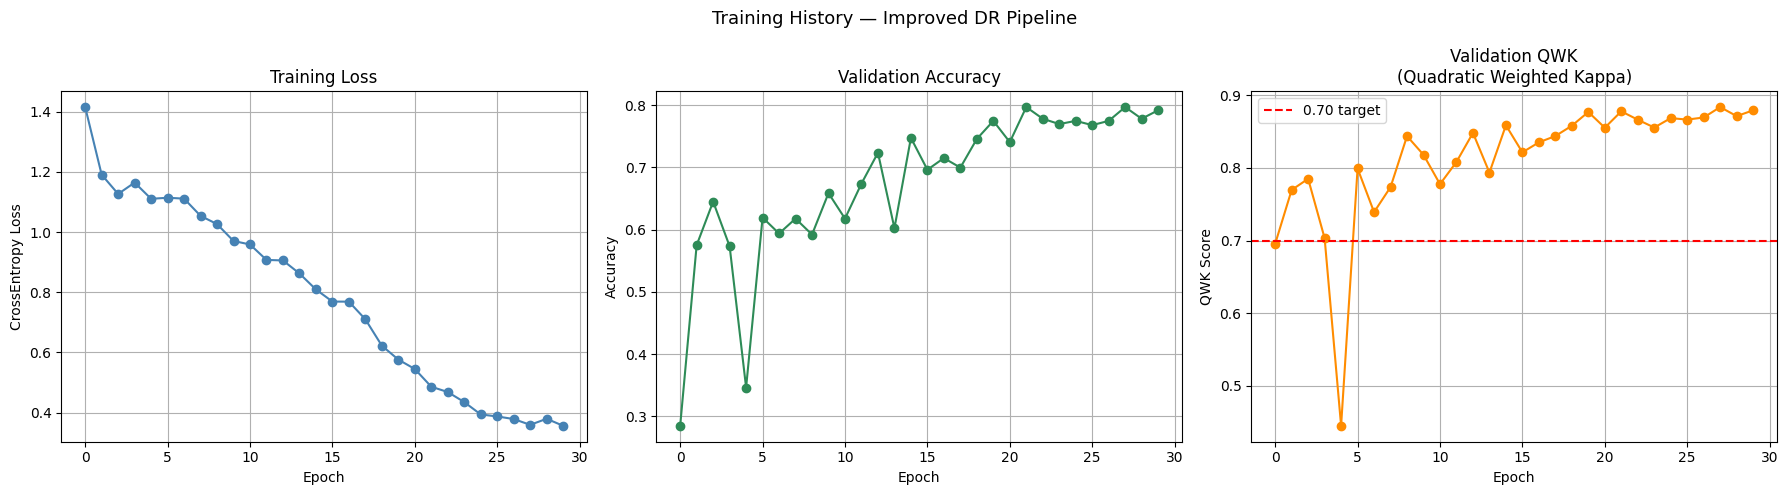

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))   # 3 panels now

axes[0].plot(history["train_loss"], marker="o", color="steelblue")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].grid(True)

axes[1].plot(history["val_acc"], marker="o", color="seagreen")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)

# NEW: QWK panel
axes[2].plot(history["val_kappa"], marker="o", color="darkorange")
axes[2].set_title("Validation QWK\n(Quadratic Weighted Kappa)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("QWK Score")
axes[2].axhline(0.7, color="red", linestyle="--", label="0.70 target")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Training History — Improved DR Pipeline", fontsize=13)
plt.tight_layout()
plt.show()

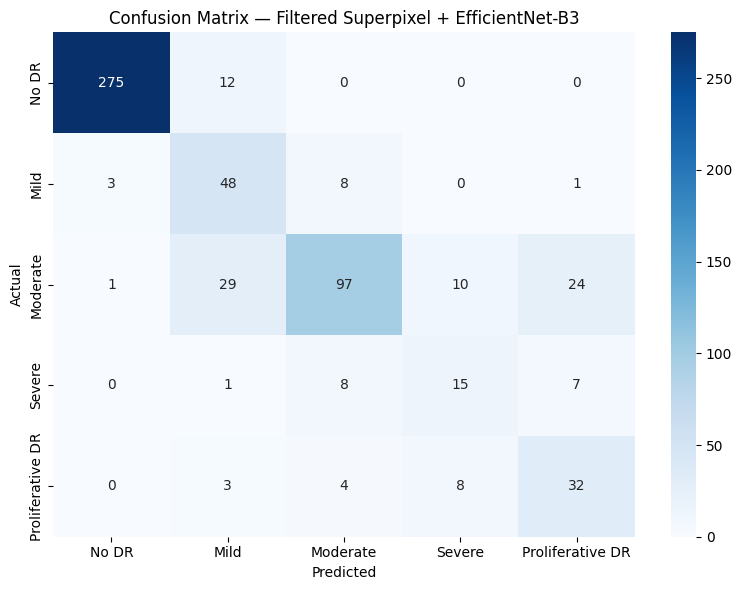


Classification Report:
                  precision    recall  f1-score   support

           No DR       0.99      0.96      0.97       287
            Mild       0.52      0.80      0.63        60
        Moderate       0.83      0.60      0.70       161
          Severe       0.45      0.48      0.47        31
Proliferative DR       0.50      0.68      0.58        47

        accuracy                           0.80       586
       macro avg       0.66      0.71      0.67       586
    weighted avg       0.83      0.80      0.80       586


Final Accuracy : 0.7969
Final QWK Score: 0.8838  ← main APTOS metric (target > 0.80)


In [ ]:
model.load_state_dict(torch.load("/content/best_model.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs  = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=list(GRADE_LABELS.values()),
    yticklabels=list(GRADE_LABELS.values())
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Filtered Superpixel + EfficientNet-B3")
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=list(GRADE_LABELS.values())
))


# Add this AFTER your existing classification_report print
final_kappa = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
final_acc   = accuracy_score(all_labels, all_preds)
print(f"\nFinal Accuracy : {final_acc:.4f}")
print(f"Final QWK Score: {final_kappa:.4f}  ← main APTOS metric (target > 0.80)")

Confidence    : 84.5%
All probs     : {'No DR': '0.0%', 'Mild': '14.1%', 'Moderate': '84.5%', 'Severe': '0.0%', 'Proliferative DR': '1.3%'}


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


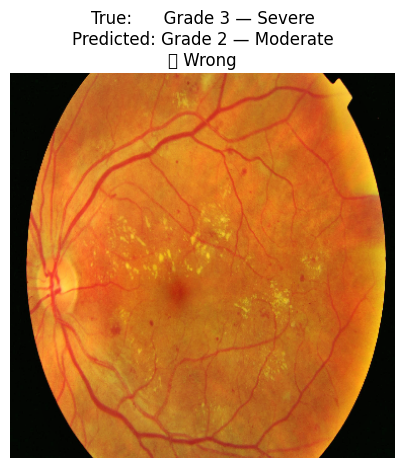

In [ ]:
def predict_single_image(img_path, model):
    model.eval()
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = apply_clahe(img)
    img = crop_to_field_of_view(img)
    img = cv2.resize(img, (380, 380))

    mask = get_superpixel_mask(img)
    img  = (img.astype(np.float32) * mask).astype(np.uint8)

    tensor = val_transform(image=img)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]

    pred = int(probs.argmax())
    print(f"Confidence    : {probs[pred]*100:.1f}%")
    print(f"All probs     : { {GRADE_LABELS[i]: f'{p*100:.1f}%' for i,p in enumerate(probs)} }")
    return pred


# Test on a sample
test_row  = df.sample(1, random_state=7).iloc[0]
pred      = predict_single_image(test_row["img_path"], model)
true      = test_row["diagnosis"]
_, img_rgb = preprocess_image(test_row["img_path"], return_rgb=True)

plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(
    f"True:      Grade {true} — {GRADE_LABELS[true]}\n"
    f"Predicted: Grade {pred} — {GRADE_LABELS[pred]}\n"
    f"{'✅ Correct' if pred == true else '❌ Wrong'}"
)
plt.axis("off")
plt.show()

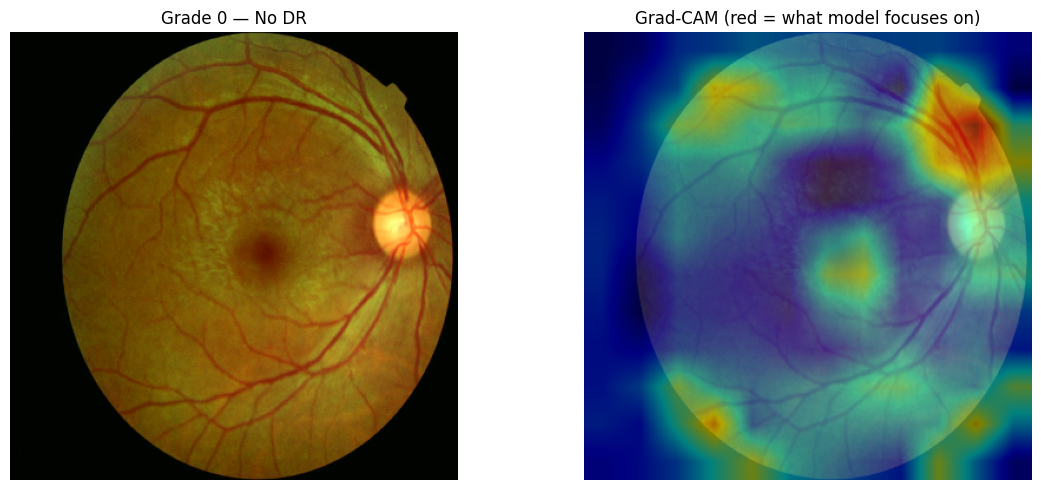

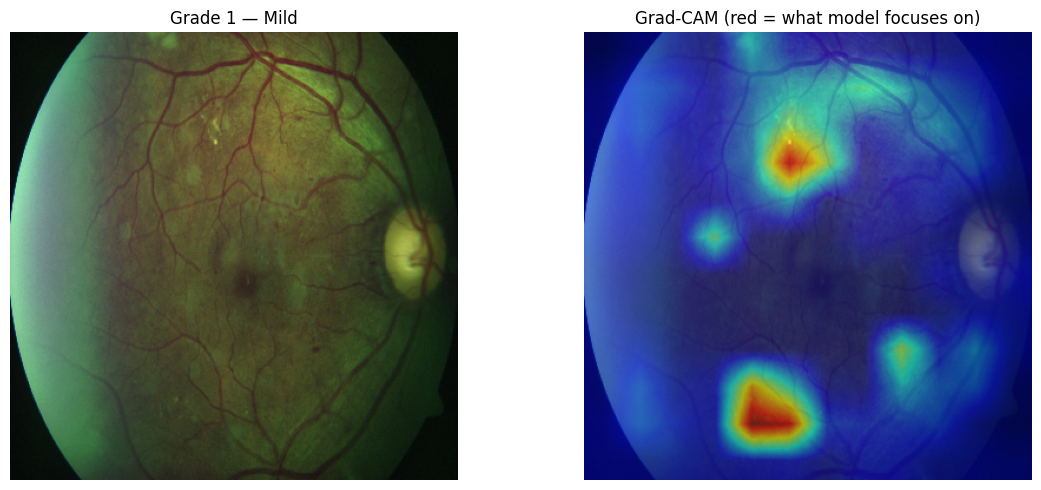

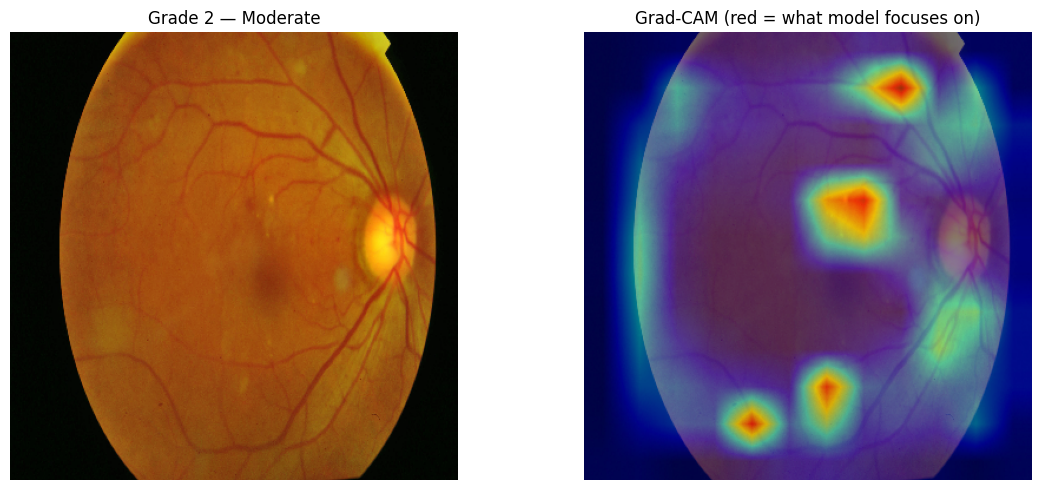

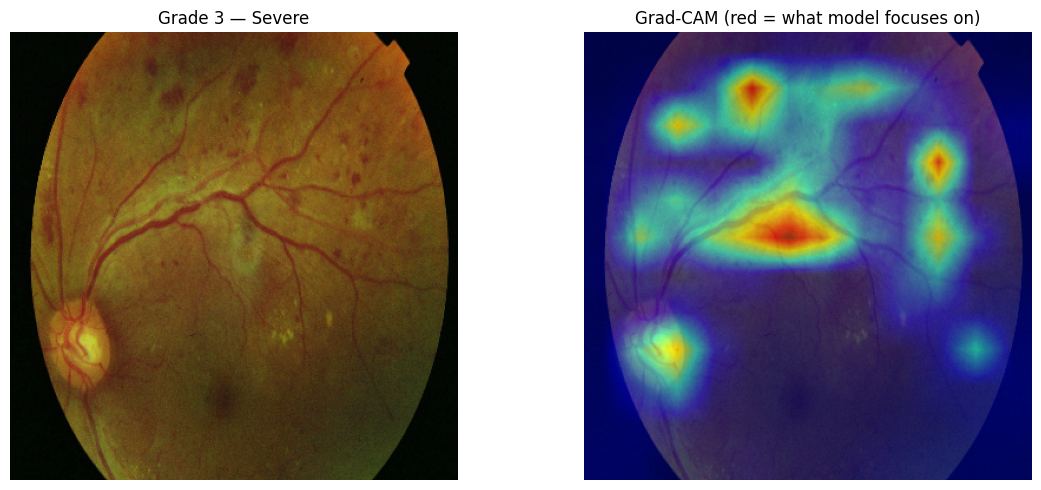

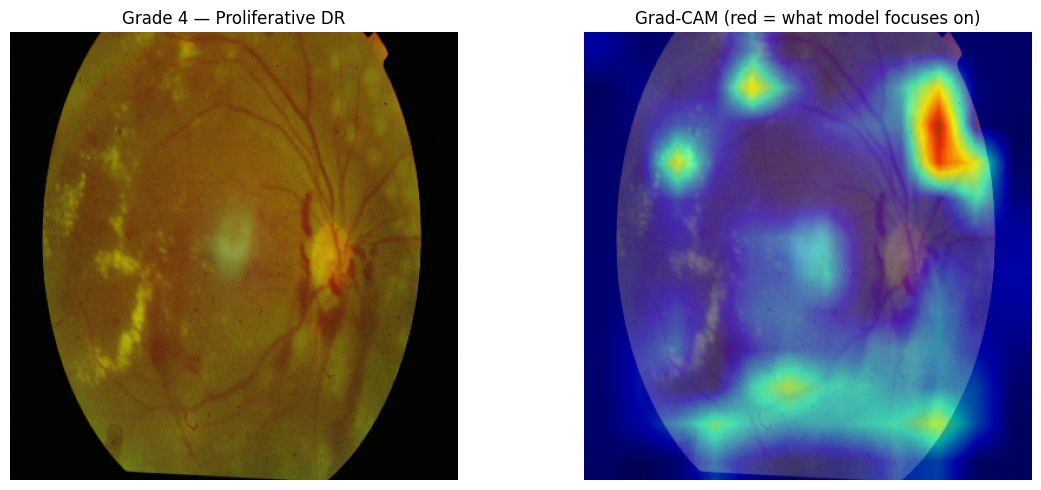

In [ ]:
# Grad-CAM — shows what the model looks at for each grade
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def show_gradcam(img_path, model, true_label):
    _, img_rgb = preprocess_image(img_path, return_rgb=True)
    tensor     = val_transform(image=img_rgb)["image"].unsqueeze(0).to(device)

    cam            = GradCAM(model=model, target_layers=[model.features[-1]])
    grayscale_cam  = cam(input_tensor=tensor)[0]
    img_float      = img_rgb.astype(np.float32) / 255.0
    visualization  = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Grade {true_label} — {GRADE_LABELS[true_label]}")
    axes[0].axis("off")
    axes[1].imshow(visualization)
    axes[1].set_title("Grad-CAM (red = what model focuses on)")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

for grade in range(5):
    sample = df[df["diagnosis"] == grade].iloc[0]
    show_gradcam(sample["img_path"], model, grade)